# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('data/am_pm.csv')

In [3]:
def plot_w_decision_boundary(ax, model, X, y, title):
    DecisionBoundaryDisplay.from_estimator(model, X, ax=ax, alpha=0.3, cmap='RdBu',
                                           response_method='predict', grid_resolution=500)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', s=50, alpha=0.7)
    ax.set(xlabel='AM', ylabel='PM', title=title)
    ax.grid(True, alpha=0.3)


In [4]:
X = df[['am', 'pm']].values
y = (df['target'] == 'weekend').astype(int).values

logreg = LogisticRegression(random_state=21, fit_intercept=False).fit(X, y)

y_pred_logreg = logreg.predict(X)

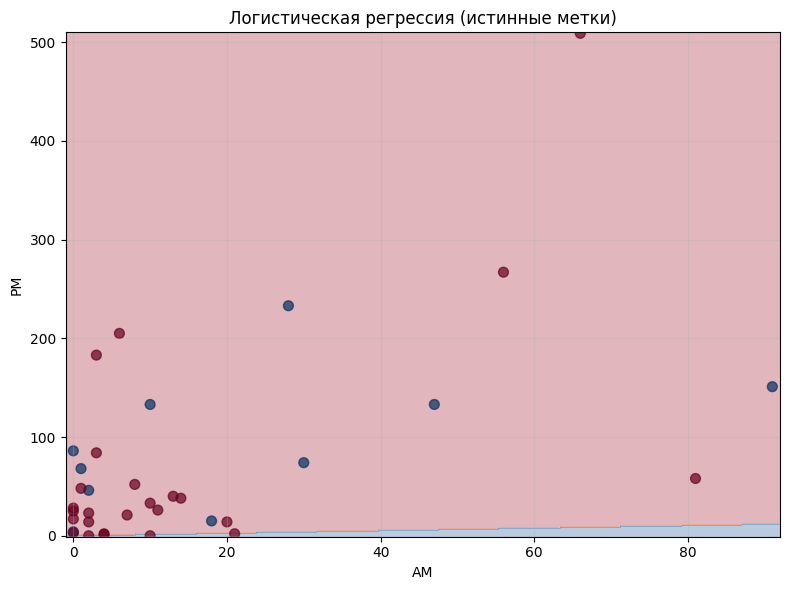

In [5]:
plt.figure(figsize=(8, 6))

plot_w_decision_boundary(plt.gca(), logreg, X, y, 'Логистическая регрессия (истинные метки)')

plt.tight_layout()
plt.show()

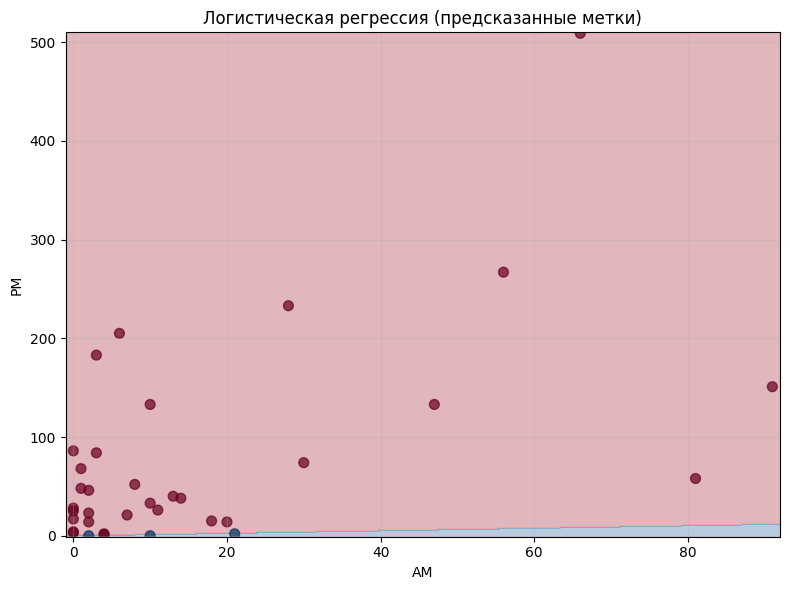

In [6]:
plt.figure(figsize=(8, 6))

plot_w_decision_boundary(plt.gca(), logreg, X, y_pred_logreg,
                        'Логистическая регрессия (предсказанные метки)')

plt.tight_layout()
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [7]:
X_scaled = StandardScaler().fit_transform(X)

logreg_scaled = LogisticRegression(random_state=21, fit_intercept=False).fit(X_scaled, y)

y_pred_logreg_scaled = logreg_scaled.predict(X_scaled)

In [8]:
accuracy_logreg_scaled = accuracy_score(y, y_pred_logreg_scaled)
print(f"Accuracy логистической регрессии с масштабированием: {accuracy_logreg_scaled}")

most_common = np.bincount(y).argmax()
y_naive = np.full_like(y, most_common)
accuracy_naive = accuracy_score(y, y_naive)
print(f"Accuracy наивного классификатора: {accuracy_naive}")
print(f"Улучшение по сравнению с наивным: {(accuracy_logreg_scaled - accuracy_naive)}")

Accuracy логистической регрессии с масштабированием: 0.7428571428571429
Accuracy наивного классификатора: 0.7142857142857143
Улучшение по сравнению с наивным: 0.02857142857142858


**Улучшение качества логистической регрессии по сравнению с наивным классификатором незначительно.**

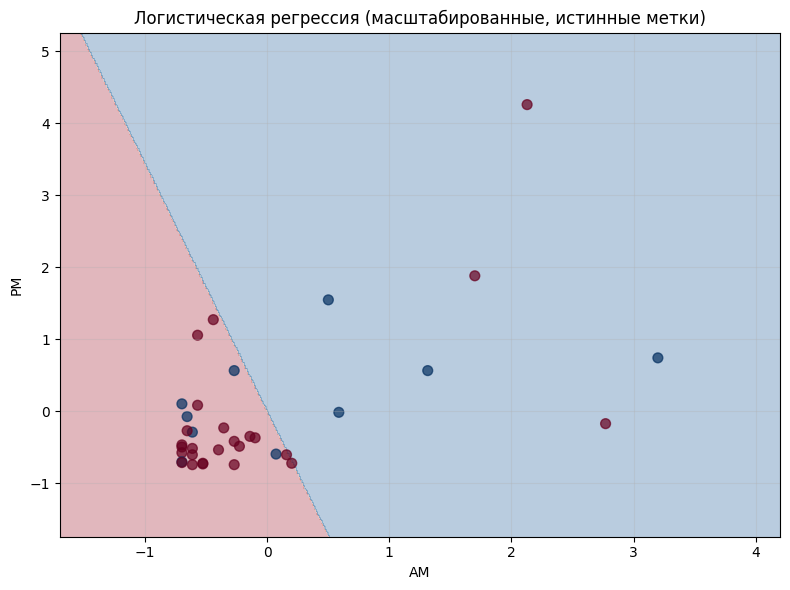

In [9]:
plt.figure(figsize=(8, 6))
plot_w_decision_boundary(plt.gca(), logreg_scaled, X_scaled, y,
                        'Логистическая регрессия (масштабированные, истинные метки)')
plt.tight_layout()
plt.show()

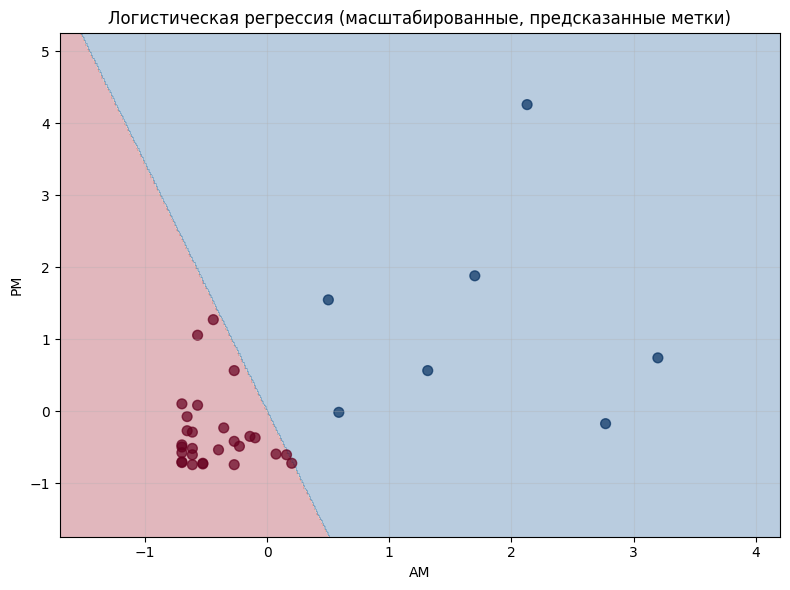

In [10]:
plt.figure(figsize=(8, 6))
plot_w_decision_boundary(plt.gca(), logreg_scaled, X_scaled, y_pred_logreg_scaled,
                        'Логистическая регрессия (масштабированные, предсказанные метки)')
plt.tight_layout()
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [11]:
svm_linear = SVC(kernel='linear', probability=True, random_state=21).fit(X_scaled, y)

y_pred_svm_linear = svm_linear.predict(X_scaled)
accuracy_svm_linear = accuracy_score(y, y_pred_svm_linear)

print(f"SVM с kernel='linear': accuracy = {accuracy_svm_linear}")

SVM с kernel='linear': accuracy = 0.7142857142857143


In [12]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=21).fit(X_scaled, y)

y_pred_svm_rbf = svm_rbf.predict(X_scaled)
accuracy_svm_rbf = accuracy_score(y, y_pred_svm_rbf)

print(f"SVM с kernel='rbf': accuracy = {accuracy_svm_rbf}")

SVM с kernel='rbf': accuracy = 0.7428571428571429


In [13]:
svm_poly = SVC(kernel='poly', probability=True, random_state=21).fit(X_scaled, y)

y_pred_svm_poly = svm_poly.predict(X_scaled)
accuracy_svm_poly = accuracy_score(y, y_pred_svm_poly)

print(f"SVM с kernel='poly': accuracy = {accuracy_svm_poly}")

SVM с kernel='poly': accuracy = 0.7428571428571429


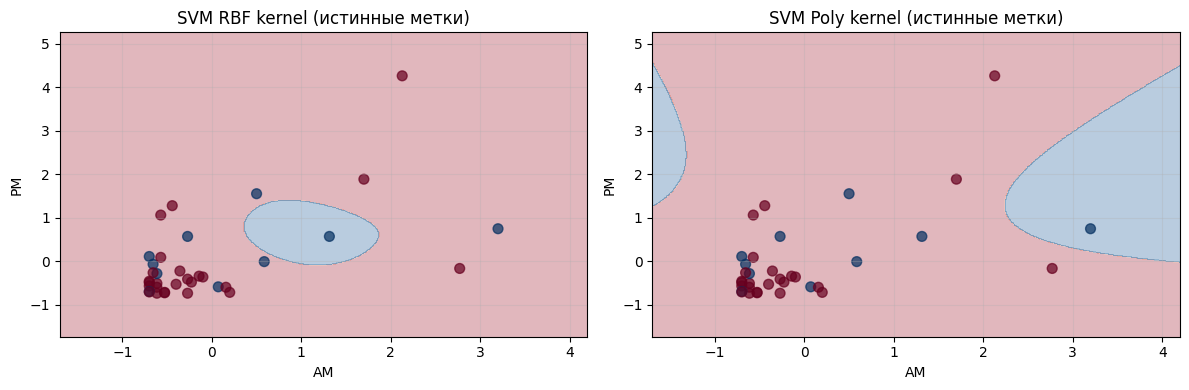

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_w_decision_boundary(axes[0], svm_rbf, X_scaled, y,
                       'SVM RBF kernel (истинные метки)')

plot_w_decision_boundary(axes[1], svm_poly, X_scaled, y,
                       'SVM Poly kernel (истинные метки)')

plt.tight_layout()
plt.show()

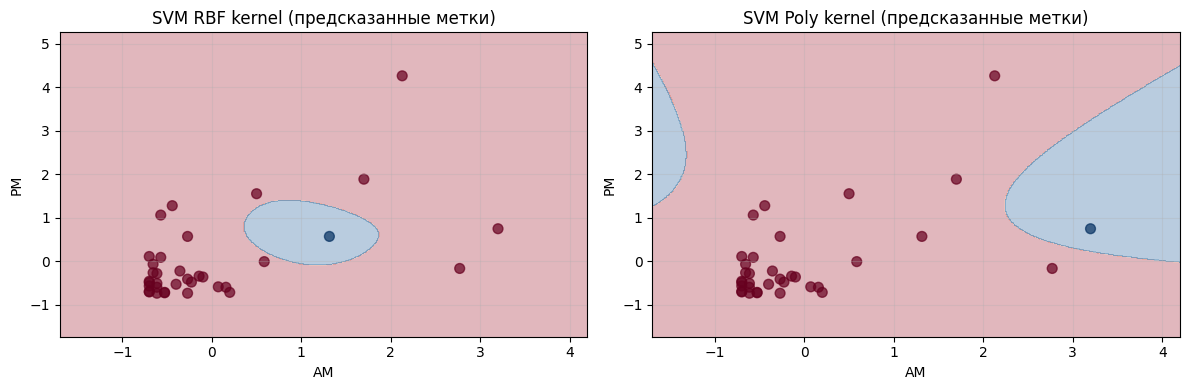

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_pred_rbf = svm_rbf.predict(X_scaled)
plot_w_decision_boundary(axes[0], svm_rbf, X_scaled, y_pred_rbf,
                       'SVM RBF kernel (предсказанные метки)')

y_pred_poly = svm_poly.predict(X_scaled)
plot_w_decision_boundary(axes[1], svm_poly, X_scaled, y_pred_poly,
                       'SVM Poly kernel (предсказанные метки)')

plt.tight_layout()
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [16]:
d_tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_scaled, y)
y_pred_dt = d_tree.predict(X_scaled)
accuracy_dt = accuracy_score(y, y_pred_dt)

print(f"Decision Tree (max_depth=4): accuracy = {accuracy_dt}")

Decision Tree (max_depth=4): accuracy = 0.9428571428571428


In [17]:
max_depths = [1, 2, 3, 4, 5, 6, 7, 8]
dt_results = {}

print("\nПоиск лучшего max_depth для Decision Tree:")
print("-" * 40)

for md in max_depths:
    dt_test = DecisionTreeClassifier(max_depth=md, random_state=42)
    dt_test.fit(X_scaled, y)
    y_pred_test = dt_test.predict(X_scaled)
    acc = accuracy_score(y, y_pred_test)
    dt_results[md] = (dt_test, acc)
    print(f"max_depth={md}: accuracy = {acc}")

best_max_depth = max(dt_results, key=lambda k: dt_results[k][1])
best_dt = dt_results[best_max_depth][0]
best_dt_accuracy = dt_results[best_max_depth][1]

print(f"\nЛучший минимальный max_depth: {best_max_depth} (accuracy = {best_dt_accuracy})")
print("-" * 40)


Поиск лучшего max_depth для Decision Tree:
----------------------------------------
max_depth=1: accuracy = 0.7714285714285715
max_depth=2: accuracy = 0.8571428571428571
max_depth=3: accuracy = 0.8857142857142857
max_depth=4: accuracy = 0.9428571428571428
max_depth=5: accuracy = 0.9714285714285714
max_depth=6: accuracy = 1.0
max_depth=7: accuracy = 1.0
max_depth=8: accuracy = 1.0

Лучший минимальный max_depth: 6 (accuracy = 1.0)
----------------------------------------


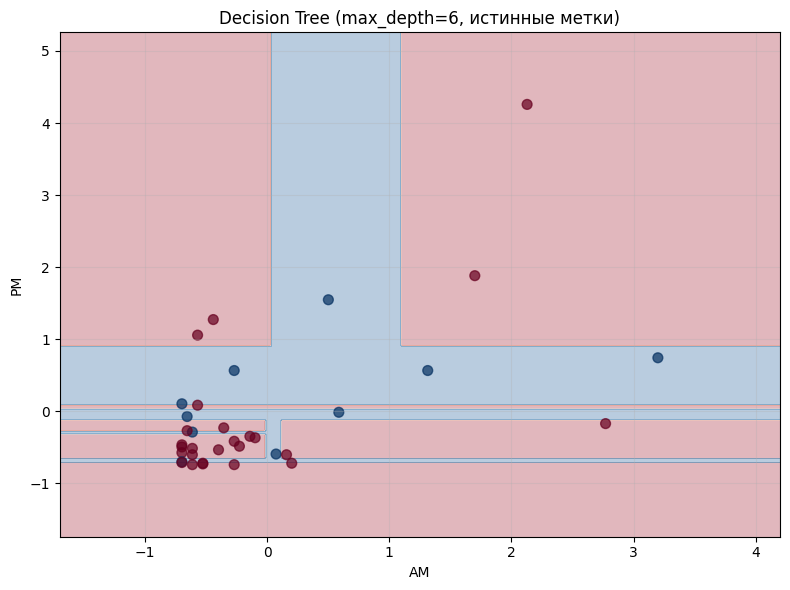

In [18]:
fig = plt.figure(figsize=(8, 6))
plot_w_decision_boundary(plt.gca(), best_dt, X_scaled, y,
                         f'Decision Tree (max_depth={best_max_depth}, истинные метки)')
plt.tight_layout()
plt.show()

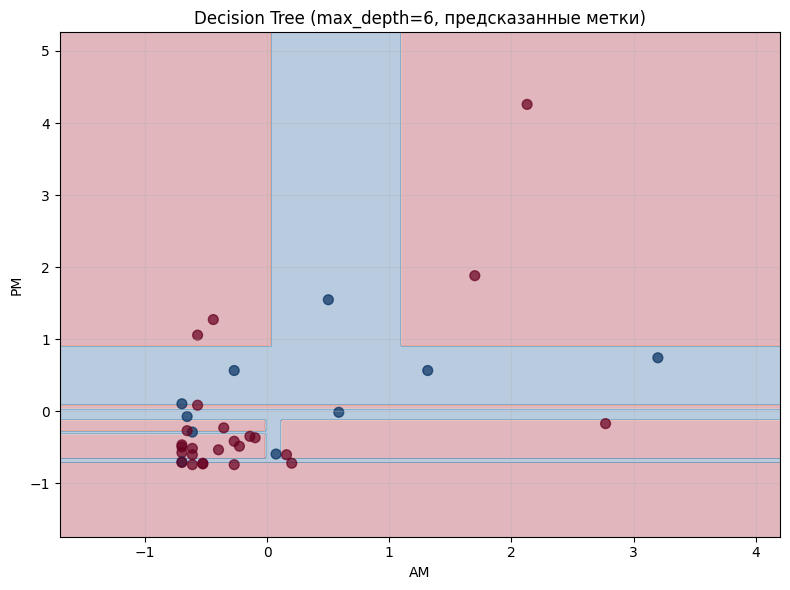

In [19]:
fig = plt.figure(figsize=(8, 6))
plot_w_decision_boundary(plt.gca(), best_dt, X_scaled, best_dt.predict(X_scaled),
                         f'Decision Tree (max_depth={best_max_depth}, предсказанные метки)')
plt.tight_layout()
plt.show()

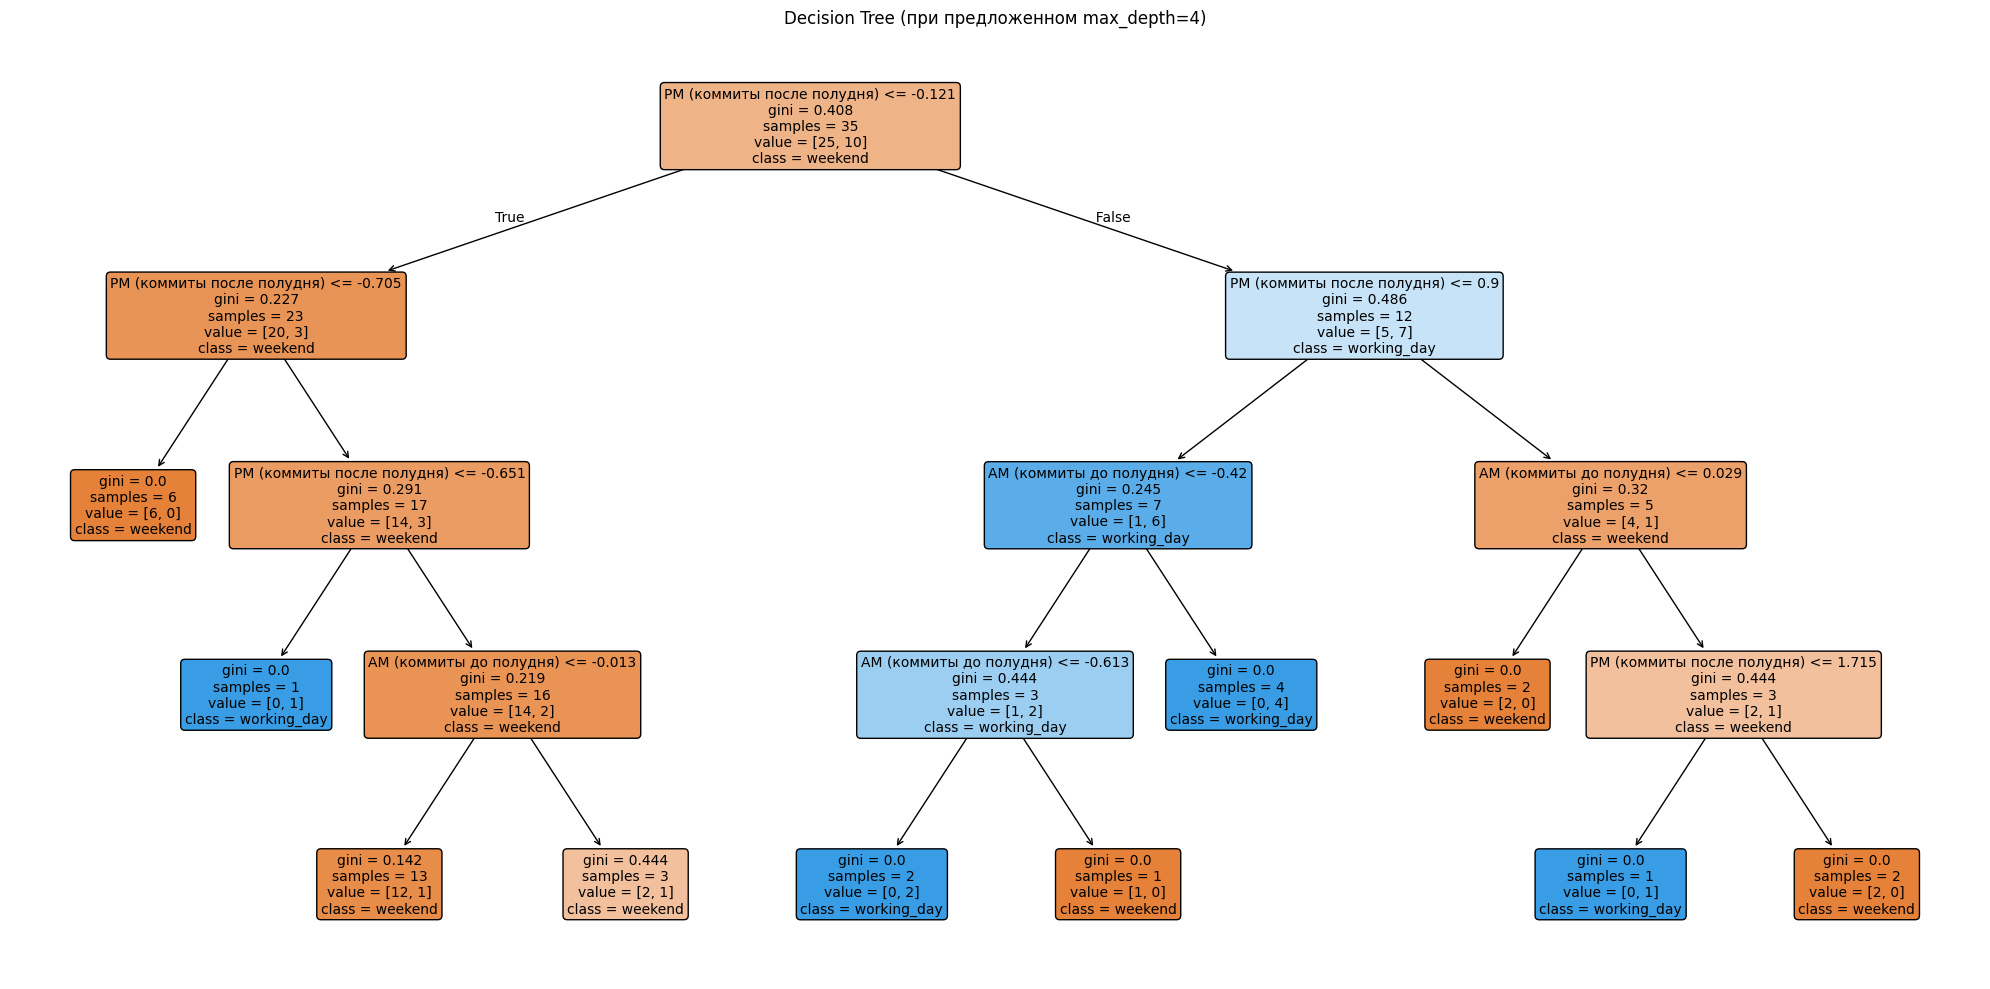

In [20]:
fig = plt.figure(figsize=(20, 10))
plot_tree(d_tree, 
          feature_names=['AM (коммиты до полудня)', 'PM (коммиты после полудня)'],
          class_names=['weekend', 'working_day'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f'Decision Tree (при предложенном max_depth=4)')
plt.tight_layout()
plt.show()

Сколько листьев, согласно визуализации дерева решений при max_depth=4, классифицируют рабочие дни?

**Ответ: 4** (из 10)